# Video Game Sales EDA

## Goal
Explore the video game sales dataset using pandas and compare key findings with SQL analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


sns.set_style("whitegrid")

In [2]:
os.chdir(r"C:\Users\user\sql_pandas_eda")

In [3]:
df = pd.read_csv("data/raw/vgsales.csv")
df.head(10)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


In [4]:
df.info()
df.describe()
df.shape
df.columns
df.dtypes


<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.4 MB


Rank              int64
Name                str
Platform            str
Year            float64
Genre               str
Publisher           str
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

In [5]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

## Analysis Questions

1. Which platforms have the highest total global sales?
2. Which genres have the highest average global sales?
3. Which publishers appear most often?
4. How do sales change by year?
5. Which games are the top 10 by global sales?

## 1. Top Platforms by Total Global Sales

In [6]:
top_platforms = (
    df.groupby("Platform")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_platforms 

Platform
PS2     1255.64
X360     979.96
PS3      957.84
Wii      926.71
DS       822.49
PS       730.66
GBA      318.50
PSP      296.28
PS4      278.10
PC       258.82
Name: Global_Sales, dtype: float64

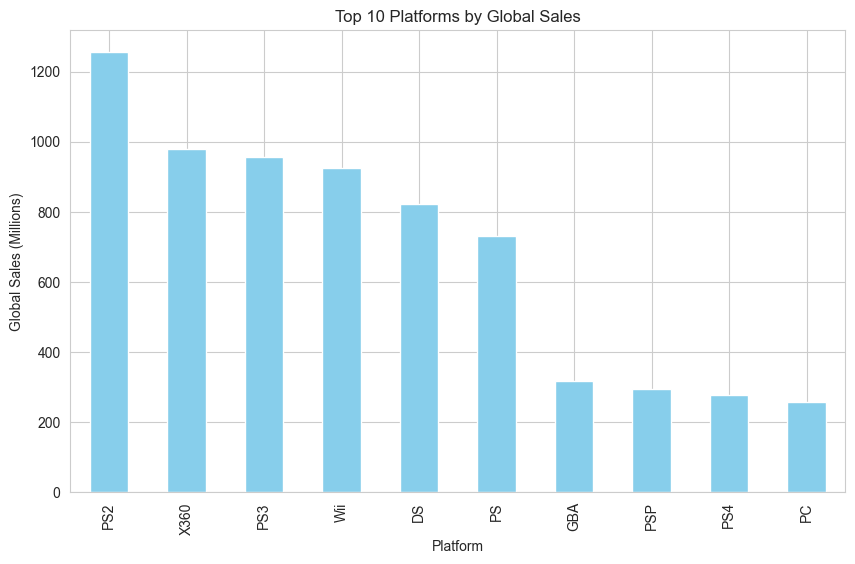

In [7]:
top_platforms.plot(kind="bar", figsize=(10,6), color="skyblue")
plt.title("Top 10 Platforms by Global Sales")
plt.xlabel("Platform")
plt.ylabel("Global Sales (Millions)")   
plt.show()

PS2 leads total global sales, followed by X360 and PS3.

## 2. Genres with highest avarage Global Sales

In [8]:
top_genres = (
    df.groupby("Genre")["Global_Sales"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_genres 

Genre
Platform        0.938341
Shooter         0.791885
Role-Playing    0.623233
Racing          0.586101
Sports          0.567319
Fighting        0.529375
Action          0.528100
Misc            0.465762
Simulation      0.452364
Puzzle          0.420876
Name: Global_Sales, dtype: float64

Platform has the highest average global sales per game, followed by Shooter and Role-Playing. This suggests some genres tend to produce higher-selling games on average than others.

## 3. Publishers who appear most often

In [9]:
top_app_publishers = (
    df["Publisher"]
    .value_counts()
    .head(10)
)

top_app_publishers

Publisher
Electronic Arts                 1351
Activision                       975
Namco Bandai Games               932
Ubisoft                          921
Konami Digital Entertainment     832
THQ                              715
Nintendo                         703
Sony Computer Entertainment      683
Sega                             639
Take-Two Interactive             413
Name: count, dtype: int64

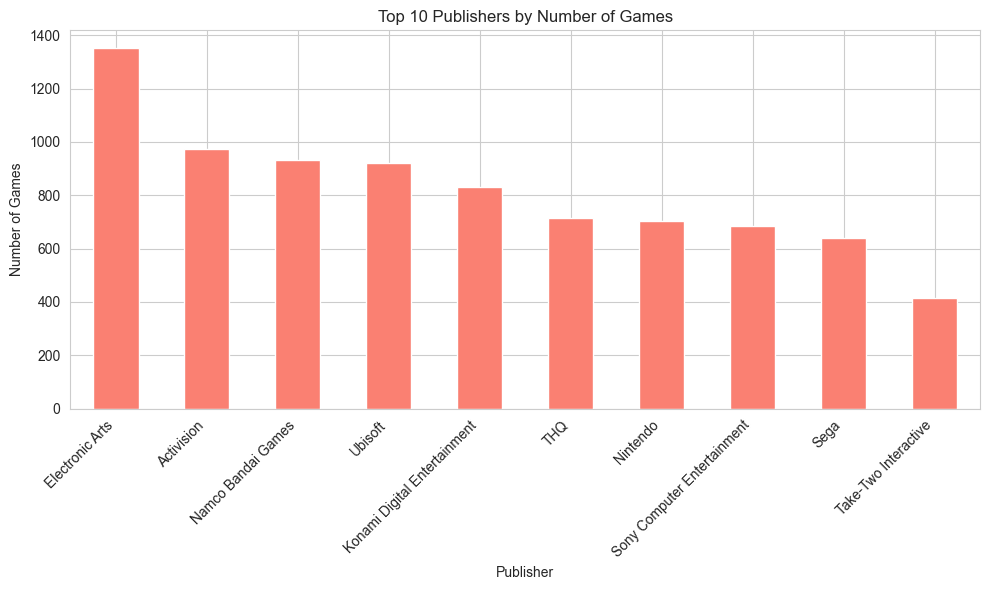

In [10]:
top_app_publishers.plot(kind="bar", figsize=(10,6), color="salmon")
plt.title("Top 10 Publishers by Number of Games")
plt.xlabel("Publisher")
plt.ylabel("Number of Games")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Electronic Arts is the publisher who appears most often with significant difference

## 4. Changes at Global Sales by Years

In [11]:
yearly_sales = (
    df.groupby("Year", as_index=False)["Global_Sales"]
    .sum()
    .sort_values("Year")
)

yearly_sales["sales_change"] = yearly_sales["Global_Sales"].diff()

yearly_sales.head(10)

,Year,Global_Sales,sales_change
0,1980.0,11.38,NaN
1,1981.0,35.77,24.39
2,1982.0,28.86,-6.91
3,1983.0,16.79,-12.07
4,1984.0,50.36,33.57
5,1985.0,53.94,3.58
6,1986.0,37.07,-16.87
7,1987.0,21.74,-15.33
8,1988.0,47.22,25.48
9,1989.0,73.45,26.23


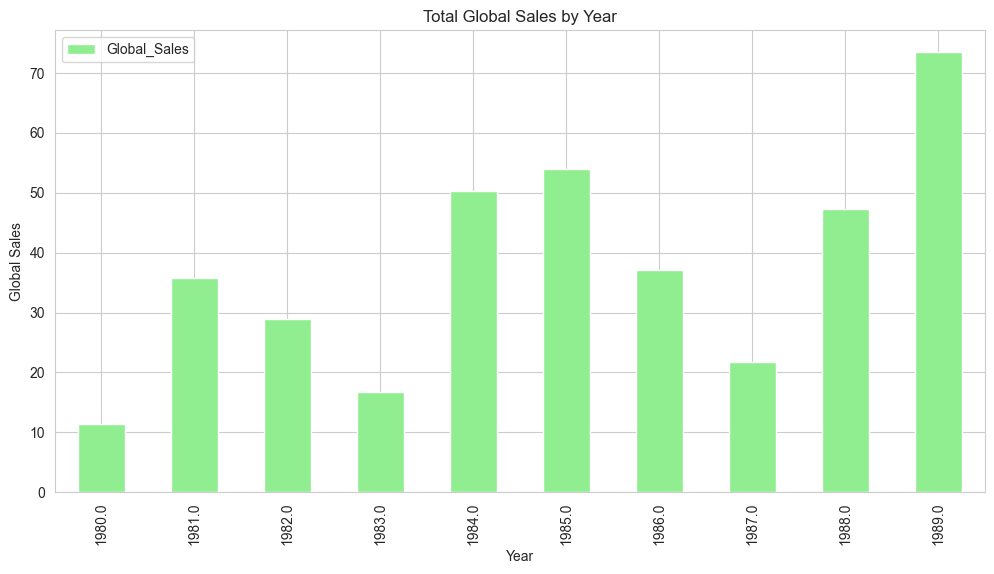

In [18]:
yearly_sales.head(10).plot(x="Year", y="Global_Sales", kind="bar", figsize=(12,6), color="lightgreen")
plt.title("Total Global Sales by Year")
plt.xlabel("Year")
plt.ylabel("Global Sales")
plt.show()

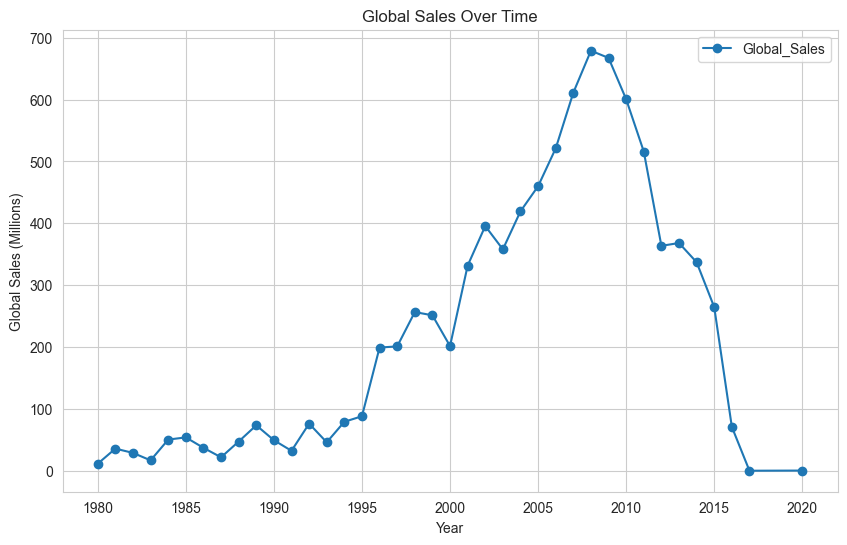

In [12]:
yearly_sales.plot(x="Year", y="Global_Sales", kind="line", marker="o", figsize=(10,6))
plt.title("Global Sales Over Time") 
plt.xlabel("Year")
plt.ylabel("Global Sales (Millions)")
plt.show()

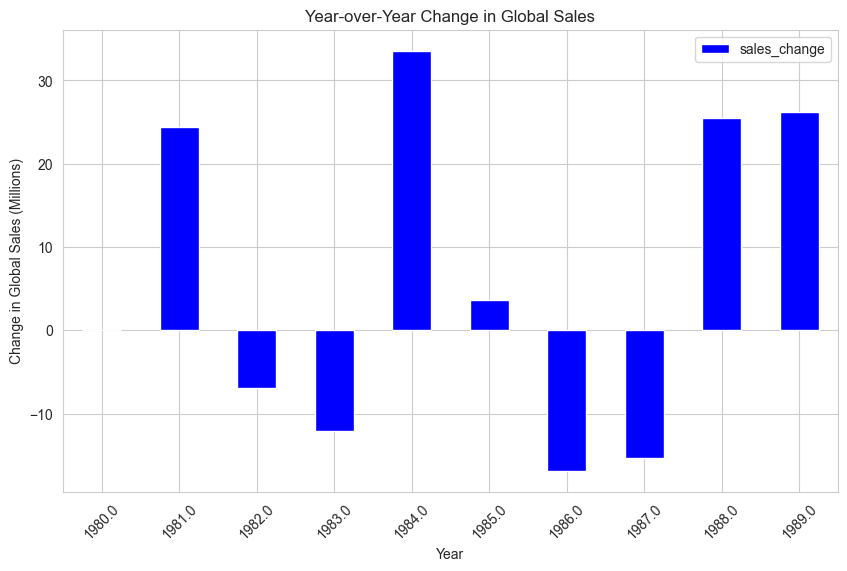

In [20]:
yearly_sales.head(10).plot(x="Year", y="sales_change", kind="bar", figsize=(10,6), color="blue")
#sns.barplot(x="Year", y="sales_change", data=yearly_sales.head(10), color="orange")
plt.title("Year-over-Year Change in Global Sales")
plt.xlabel("Year")  
plt.ylabel("Change in Global Sales (Millions)")
plt.xticks(rotation=45) 
plt.show()

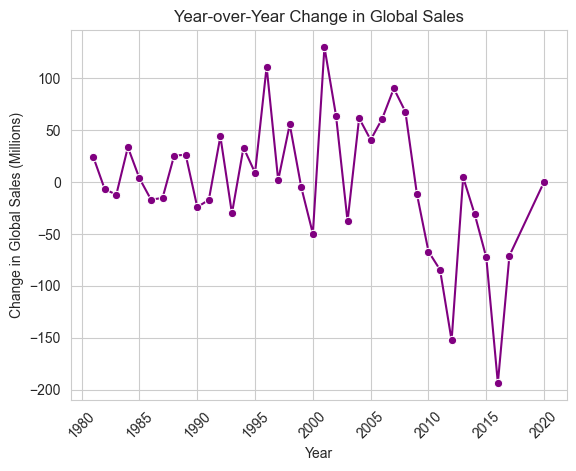

In [21]:
sns.lineplot(x="Year", y="sales_change", data=yearly_sales, marker="o", color="purple")
plt.title("Year-over-Year Change in Global Sales")
plt.xlabel("Year")
plt.ylabel("Change in Global Sales (Millions)")
plt.xticks(rotation=45)
plt.show()

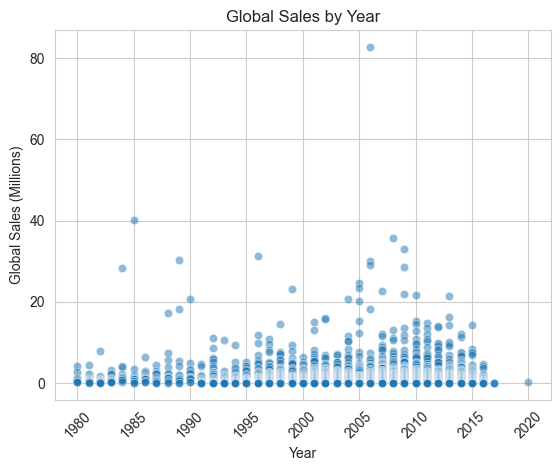

In [22]:
sns.scatterplot(x="Year", y="Global_Sales", data=df, alpha=0.5)
plt.title("Global Sales by Year")
plt.xlabel("Year")
plt.ylabel("Global Sales (Millions)")
plt.xticks(rotation=45)
plt.show()